# COMP447 Colab First Run

**Goal:** Get ECT running on a Colab T4, verify environment, do a dry-run, and launch the first sanity training.

**Runtime:** Must be **T4 GPU** (Runtime > Change runtime type > T4 GPU in browser Colab, or select T4 when connecting from VS Code Colab extension).

**How to use with AI assistance:** Run each cell, wait for output. If a cell fails, the error is saved into this `.ipynb` file and Claude can read it directly from the repo. No copy-paste needed.

---

## Cell 1: Verify GPU

**Expected output:**
```
torch: 2.x.x+cu...
cuda available: True
gpu: Tesla T4
```

If `cuda available: False` → runtime is not T4. Change runtime type and reconnect.
If gpu is not T4 (e.g. `L4`, `A100`) → still OK for dry run, but final latency numbers must come from T4.

In [1]:
import torch
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    print("vram gb:", round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1))

torch: 2.10.0+cu128
cuda available: True
gpu: NVIDIA RTX PRO 6000 Blackwell Server Edition
vram gb: 102.0


## Cell 2: (skipped) Drive mount — known issue with VS Code extension

**Known issue:** `drive.mount('/content/drive')` fails from the VS Code Colab extension with `MessageError: [dfs_ephemeral] Credentials propagation unsuccessful`. The extension uses its own OAuth flow, incompatible with the inline mount.

**Workaround for today:** skip Drive entirely. Outputs stay in `/content` during the session. For the Monday sanity run this is fine — if the session dies we re-run.

**If you want Drive later:** Command Palette → `Colab: Mount Google Drive to Server...` — this inserts a snippet that uses the extension's own auth and works. Or fall back to browser Colab for runs that need persistence.

The cell below is now a no-op placeholder.

In [2]:
# Drive mount skipped — see markdown above for reason.
# Outputs will live in /content for this session.
import os
os.makedirs("/content/COMP447_runs", exist_ok=True)
print("drive mount skipped, local output dir ready:", "/content/COMP447_runs")

drive mount skipped, local output dir ready: /content/COMP447_runs


## Cell 3: Clone the COMP447 wrapper repo

**Expected output:** listing showing `project`, `final_upload`, `readings`, `proposal_template`, `README.md`.

Note: this is only the wrapper repo. ECT and EDM are cloned fresh in the next cell by `setup_ect.sh`. That's why this clone is fast.

In [3]:
%cd /content
!rm -rf COMP447
!git clone https://github.com/bakaraman/COMP447.git
%cd /content/COMP447
!ls

/content
Cloning into 'COMP447'...
remote: Enumerating objects: 487, done.
remote: Counting objects: 100% (405/405), done.
remote: Compressing objects: 100% (385/385), done.
remote: Total 487 (delta 26), reused 394 (delta 17), pack-reused 82 (from 1)
Receiving objects: 100% (487/487), 131.69 MiB | 51.49 MiB/s, done.
Resolving deltas: 100% (42/42), done.
/content/COMP447
final_upload  project  proposal_template  readings  README.md


## Cell 4: Clone ECT and EDM upstream repos

**Expected output:** two `Cloning into ...` messages, then `Bootstrap complete.` and the "Next steps" block.

This runs `project/scripts/setup_ect.sh` which clones:
- `https://github.com/locuslab/ect.git` into `project/src/ect`
- `https://github.com/NVlabs/edm.git` into `project/src/edm`

In [4]:
%cd /content/COMP447
!bash project/scripts/setup_ect.sh

/content/COMP447
Repo root: /content/COMP447

Cloning or refreshing ECT...
Cloning into '/content/COMP447/project/src/ect'...
remote: Enumerating objects: 123, done.
remote: Counting objects: 100% (123/123), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 123 (delta 65), reused 96 (delta 41), pack-reused 0 (from 0)
Receiving objects: 100% (123/123), 823.47 KiB | 7.04 MiB/s, done.
Resolving deltas: 100% (65/65), done.
  patched: InfiniteSampler.__init__ for torch >= 2.2

Cloning or refreshing EDM...
Cloning into '/content/COMP447/project/src/edm'...
remote: Enumerating objects: 54, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 54 (delta 13), reused 9 (delta 9), pack-reused 19 (from 1)
Receiving objects: 100% (54/54), 2.13 MiB | 14.04 MiB/s, done.
Resolving deltas: 100% (13/13), done.

Bootstrap complete.

Next steps:
  1. Create the runtime environment shown in:
     - /content/COMP447/project/src/

## Cell 5: Install missing Python packages

**Expected output:** a short pip install log, no errors. Colab already has torch, numpy, scipy, pillow, tqdm preinstalled, so this only fills in the rest.

If `diffusers==0.26.3` or `accelerate==0.27.2` pins conflict with Colab's preinstalled versions, we'll relax them — report back.

In [5]:
!pip install -q psutil click requests pyspng imageio-ffmpeg diffusers==0.26.3 accelerate==0.27.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 27.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.9/193.9 kB 23.6 MB/s eta 0:00:00


## Cell 6: Prepare CIFAR-10 in EDM format

**Expected output:**
- `cifar-10-python.tar.gz` downloaded (~170 MB)
- `datasets/cifar10-32x32.zip` created (~180 MB)
- Final `ls -lh datasets` shows the zip

`dataset_tool.py` converts the raw CIFAR to the EDM/ECT training format (zipped uint8 images + labels).

In [6]:
%cd /content/COMP447/project/src/ect
!mkdir -p datasets
!wget -nc -q --show-progress -O /content/cifar-10-python.tar.gz https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!python3 dataset_tool.py --source=/content/cifar-10-python.tar.gz --dest=datasets/cifar10-32x32.zip
!ls -lh datasets

/content/COMP447/project/src/ect
/content/cifar-10-p 100%[===================>] 162.60M  53.3MB/s    in 3.1s    
  0% 0/50000 [00:00<?, ?it/s]/content/COMP447/project/src/ect/dataset_tool.py:425: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  img = PIL.Image.fromarray(img, {1: 'L', 3: 'RGB'}[channels])
100% 50000/50000 [00:04<00:00, 10905.13it/s]
total 159M
-rw-r--r-- 1 root root 159M Apr 20 17:35 cifar10-32x32.zip


## Cell 7: Import smoke test

**Expected output:** `psutil ok`, `torch ok`, `cuda: True`, no ImportError.

This verifies that the packages ECT needs at import time are all present in the current kernel.

In [7]:
import sys, importlib
for pkg in ["psutil", "torch", "click", "PIL", "numpy", "scipy", "tqdm", "imageio", "pyspng"]:
    try:
        importlib.import_module(pkg)
        print(f"  ok  {pkg}")
    except ImportError as e:
        print(f"  MISSING  {pkg}: {e}")
import torch
print(f"\npython: {sys.version.split()[0]}")
print(f"torch:  {torch.__version__}")
print(f"cuda:   {torch.cuda.is_available()}")

  ok  psutil
  ok  torch
  ok  click
  ok  PIL
  ok  numpy
  ok  scipy
  ok  tqdm
  ok  imageio
  ok  pyspng

python: 3.12.13
torch:  2.10.0+cu128
cuda:   True


## Cell 8: Dry-run the ECT training command

**Expected output:** ECT parses training options, `dist.init()` initializes with WORLD_SIZE=1, prints the training config JSON, then exits because of `-n` / `--dry_run`. No traceback.

**Why torchrun, not `python3`:** `ct_train.py` calls `dist.init()` which invokes `torch.distributed.init_process_group(init_method='env://')`. That requires MASTER_ADDR, MASTER_PORT, RANK, WORLD_SIZE env vars. `torchrun` sets those automatically for single-process single-node runs. Calling plain `python3` would fail inside `init_process_group`.

**If it still fails, usual suspects:**
- pretrained checkpoint 404 / timeout → retry
- `diffusers==0.26.3` version conflict with torch 2.10 → we'll relax the pin
- NCCL backend errors on single-GPU → unlikely but we'd switch to `gloo`

In [8]:
%cd /content/COMP447/project/src/ect
!torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29501 \
  ct_train.py \
    --outdir=ct-runs-dry \
    --data=datasets/cifar10-32x32.zip \
    --cond=0 \
    --arch=ddpmpp \
    --metrics=fid50k_full \
    --transfer=https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl \
    --duration=0.001 \
    --batch=8 \
    --dry_run

/content/COMP447/project/src/ect

Training options:
{
  "dataset_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "datasets/cifar10-32x32.zip",
    "use_labels": false,
    "xflip": false,
    "cache": true,
    "resolution": 32,
    "max_size": 50000
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 1,
    "prefetch_factor": 2
  },
  "network_kwargs": {
    "model_type": "SongUNet",
    "embedding_type": "positional",
    "encoder_type": "standard",
    "decoder_type": "standard",
    "channel_mult_noise": 1,
    "resample_filter": [
      1,
      1
    ],
    "model_channels": 128,
    "channel_mult": [
      2,
      2,
      2
    ],
    "class_name": "training.networks.ECMPrecond",
    "augment_dim": 9,
    "dropout": 0.13,
    "use_fp16": false
  },
  "loss_kwargs": {
    "P_mean": -1.1,
    "P_std": 2.0,
    "q": 2.0,
    "c": 0.0,
    "k": 8.0,
    "b": 1.0,
    "adj": "sigmoid",
    "class_name": "training.loss.ECMLoss"
 

## Cell 8b: Mini training sanity (2-3 minutes)

**Why this cell exists:** Cell 8 (dry run) only validates config parsing and network instantiation. It does **not** run a single training step. This cell runs a few real forward+backward passes so we know:

- pretrained EDM checkpoint actually downloads and loads into the network
- the ECT loss is finite on T4 (not NaN)
- batch 64 fits in 16 GB VRAM (ECT's default batch=128 might OOM)
- torch 2.10 / cuda 12.8 / diffusers 0.26 all agree numerically

**Config:**
- `--duration=0.02` → total 20 kimg (vs Cell 9's 25,600 kimg)
- `--batch=64` → half of ECT default, safe on T4
- `--tick=1` → print a tick line every 1 kimg, so you see ~20 tick logs
- `--eval_every=1000000` + `--dump=1000000` → no FID / snapshot during mini run

**Expected output:** `Loading training set...`, `Constructing network...`, `Setting up EMA...`, then 1-20 `tick N ... kimg X ... loss Y ...` lines with finite loss, then clean exit. Total wall ~2-4 min.

**If the loss is NaN or you see CUDA OOM:** stop and report. We drop batch to 32 or enable mixed precision.

In [9]:
%cd /content/COMP447/project/src/ect

# Patch 1: ECT's InfiniteSampler is incompatible with torch >= 2.2
# torch.utils.data.Sampler.__init__ no longer takes data_source arg.
# Fixes: TypeError: object.__init__() takes exactly one argument
!sed -i 's|super().__init__(dataset)|super().__init__()|' torch_utils/misc.py
!grep -n "super().__init__" torch_utils/misc.py

# NOTE: --metrics=none disables the end-of-training FID50k evaluation which
# takes 5-15 min on T4 and is not needed for a 20-kimg sanity. The 20 ticks
# of training are what we're validating here, not FID quality.
!torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29502 \
  ct_train.py \
    --outdir=ct-runs-mini \
    --data=datasets/cifar10-32x32.zip \
    --cond=0 \
    --arch=ddpmpp \
    --precond=ect \
    --metrics=none \
    --transfer=https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl \
    --duration=0.02 \
    --tick=1 \
    --batch=64 \
    --lr=0.0001 \
    --optim=RAdam \
    --dropout=0.2 \
    --augment=0.0 \
    -q 256 \
    --double=10000 \
    --ema_beta=0.9993 \
    --eval_every=1000000 \
    --dump=1000000 \
    --snap=1000000 \
    --desc=mini_sanity

/content/COMP447/project/src/ect
116:        super().__init__()

Training options:
{
  "dataset_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "datasets/cifar10-32x32.zip",
    "use_labels": false,
    "xflip": false,
    "cache": true,
    "resolution": 32,
    "max_size": 50000
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 1,
    "prefetch_factor": 2
  },
  "network_kwargs": {
    "model_type": "SongUNet",
    "embedding_type": "positional",
    "encoder_type": "standard",
    "decoder_type": "standard",
    "channel_mult_noise": 1,
    "resample_filter": [
      1,
      1
    ],
    "model_channels": 128,
    "channel_mult": [
      2,
      2,
      2
    ],
    "class_name": "training.networks.ECMPrecond",
    "dropout": 0.2,
    "use_fp16": false
  },
  "loss_kwargs": {
    "P_mean": -1.1,
    "P_std": 2.0,
    "q": 256.0,
    "c": 0.0,
    "k": 8.0,
    "b": 1.0,
    "adj": "sigmoid",
    "class_name": "training.loss.

## Cell 9: Medium tuning with 4 ablation snapshots (2000 kimg)

Trains ECT for 2000 kimg and saves **4 snapshots** along the way for the tuning-budget ablation:

| Tick | kimg | Snapshot file |
|---|---|---|
| 50 | 500 | `network-snapshot-000050.pkl` |
| 100 | 1000 | `network-snapshot-000100.pkl` |
| 150 | 1500 | `network-snapshot-000150.pkl` |
| 200 | 2000 | `network-snapshot-000200.pkl` |

These 4 files feed Cell 10 (ablation FID eval) and Cell 12 (latency measurements).

**Key change from Cell 8b:** `--snap=50` saves a snapshot every 50 ticks. With `--tick=10`, one snapshot per 500 kimg. Also `--metrics=none` to skip intermediate FID eval (we do this explicitly in Cell 10).

**Expected wall time:**
- G4 / Blackwell: ~15 min
- L4: ~30 min
- T4: ~1.5 hours (use a faster GPU)

**Compute budget:** G4 ~10-12 units, L4 ~2-3 units.

**DO NOT** run on T4 — too slow. Switch runtime before this cell if you're on T4.

In [10]:
%cd /content/COMP447/project/src/ect

# Patch is idempotent — safe to re-run
!sed -i 's|super().__init__(dataset)|super().__init__()|' torch_utils/misc.py

!torchrun --nnodes=1 --nproc_per_node=1 --rdzv_backend=c10d --rdzv_endpoint=localhost:29503 \
  ct_train.py \
    --outdir=ct-runs-medium \
    --data=datasets/cifar10-32x32.zip \
    --cond=0 \
    --arch=ddpmpp \
    --precond=ect \
    --metrics=none \
    --transfer=https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl \
    --duration=2.0 \
    --tick=10 \
    --batch=128 \
    --lr=0.0001 \
    --optim=RAdam \
    --dropout=0.2 \
    --augment=0.0 \
    -q 256 \
    --double=10000 \
    --ema_beta=0.9993 \
    --eval_every=1000000 \
    --dump=1000000 \
    --snap=50 \
    --desc=medium_2k

/content/COMP447/project/src/ect

Training options:
{
  "dataset_kwargs": {
    "class_name": "training.dataset.ImageFolderDataset",
    "path": "datasets/cifar10-32x32.zip",
    "use_labels": false,
    "xflip": false,
    "cache": true,
    "resolution": 32,
    "max_size": 50000
  },
  "data_loader_kwargs": {
    "pin_memory": true,
    "num_workers": 1,
    "prefetch_factor": 2
  },
  "network_kwargs": {
    "model_type": "SongUNet",
    "embedding_type": "positional",
    "encoder_type": "standard",
    "decoder_type": "standard",
    "channel_mult_noise": 1,
    "resample_filter": [
      1,
      1
    ],
    "model_channels": 128,
    "channel_mult": [
      2,
      2,
      2
    ],
    "class_name": "training.networks.ECMPrecond",
    "dropout": 0.2,
    "use_fp16": false
  },
  "loss_kwargs": {
    "P_mean": -1.1,
    "P_std": 2.0,
    "q": 256.0,
    "c": 0.0,
    "k": 8.0,
    "b": 1.0,
    "adj": "sigmoid",
    "class_name": "training.loss.ECMLoss"
  },
  "optimizer_kwar

## Cell 10: ECT ablation FID evaluation

Runs `ct_eval.py` on each of the 4 snapshots from Cell 9 to get **1-step** and **2-step FID50k** for each training budget (500 / 1000 / 1500 / 2000 kimg).

ECT's eval produces two metrics automatically:
- `fid50k_full` → 1-step generation FID (50,000 samples)
- `two_step_fid50k_full` → 2-step generation FID with default `mid_t=0.821`

**Expected time per snapshot on G4:** ~3-5 min (dominated by 50k sample generation + inception feature extraction).
**Total for 4 snapshots: ~15-20 min.**

**Output:** `project/results/ablation_fid.csv` with columns `kimg, tick, fid_1step, fid_2step, snapshot`.

This is the **tuning-budget ablation data** — feeds the "quality vs training time" curve.

In [11]:
import os, glob, json, subprocess, csv
from pathlib import Path

%cd /content/COMP447/project/src/ect

# Find the most recent medium training run
run_dirs = sorted(glob.glob("ct-runs-medium/*-medium_2k"))
if not run_dirs:
    raise RuntimeError("No ct-runs-medium/*-medium_2k dir found. Run Cell 9 first.")
run_dir = run_dirs[-1]
print(f"Using run dir: {run_dir}")

# Find all snapshots (exclude 'latest')
snapshots = sorted(glob.glob(f"{run_dir}/network-snapshot-*.pkl"))
snapshots = [s for s in snapshots if "latest" not in s]
print(f"Found {len(snapshots)} snapshots: {[Path(s).name for s in snapshots]}\n")

results_dir = Path("/content/COMP447/project/results")
results_dir.mkdir(exist_ok=True, parents=True)

KIMG_PER_TICK = 10  # must match Cell 9's --tick=10

rows = []
for snap in snapshots:
    tick = int(Path(snap).stem.split("-")[-1])
    kimg = tick * KIMG_PER_TICK
    print(f"=== Evaluating snapshot tick {tick} ({kimg} kimg) ===")

    eval_outdir = f"ct-evals/snap-{tick:06d}"

    cmd = [
        "torchrun", "--nnodes=1", "--nproc_per_node=1",
        "--rdzv_backend=c10d", "--rdzv_endpoint=localhost:29510",
        "ct_eval.py",
        "--outdir", eval_outdir,
        "--data", "datasets/cifar10-32x32.zip",
        "--cond=0",
        "--arch=ddpmpp",
        "--precond=ct",
        "--metrics=fid50k_full",
        "--resume", snap,
        "--desc", f"ablation_{kimg}kimg",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    if result.returncode != 0:
        print("EVAL FAILED. STDERR:", result.stderr[-1500:])
        continue

    # Parse the JSON result lines from stdout
    fid_1step, fid_2step = None, None
    for line in result.stdout.split("\n"):
        line = line.strip()
        if line.startswith("{") and '"metric"' in line and '"results"' in line:
            try:
                d = json.loads(line)
                metric_name = d.get("metric", "")
                fid_val = d.get("results", {}).get("fid50k_full")
                if "two_step" in metric_name:
                    fid_2step = fid_val
                else:
                    fid_1step = fid_val
            except Exception:
                pass

    print(f"  {kimg:5d} kimg: 1-step FID={fid_1step}, 2-step FID={fid_2step}\n")
    rows.append({"kimg": kimg, "tick": tick, "fid_1step": fid_1step, "fid_2step": fid_2step, "snapshot": snap})

csv_path = results_dir / "ablation_fid.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["kimg", "tick", "fid_1step", "fid_2step", "snapshot"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved ablation FID to {csv_path}")
print("\n=== Summary ===")
for r in rows:
    if r["fid_1step"] is None and r["fid_2step"] is None:
        print(f"  {r['kimg']:5d} kimg: evaluation failed")
    else:
        f1 = f"{r['fid_1step']:.2f}" if r["fid_1step"] is not None else "—"
        f2 = f"{r['fid_2step']:.2f}" if r["fid_2step"] is not None else "—"
        print(f"  {r['kimg']:5d} kimg: 1-step FID {f1} / 2-step FID {f2}")

/content/COMP447/project/src/ect
Using run dir: ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k
Found 4 snapshots: ['network-snapshot-000050.pkl', 'network-snapshot-000100.pkl', 'network-snapshot-000150.pkl', 'network-snapshot-000198.pkl']

=== Evaluating snapshot tick 50 (500 kimg) ===
    500 kimg: 1-step FID=8.135476124822045, 2-step FID=None

=== Evaluating snapshot tick 100 (1000 kimg) ===
   1000 kimg: 1-step FID=2.7730464596706557, 2-step FID=None

=== Evaluating snapshot tick 150 (1500 kimg) ===
   1500 kimg: 1-step FID=2.7021001419223447, 2-step FID=None

=== Evaluating snapshot tick 198 (1980 kimg) ===
   1980 kimg: 1-step FID=2.446277615255744, 2-step FID=None


✓ Saved ablation FID to /content/COMP447/project/results/ablation_fid.csv

=== Summary ===
    500 kimg: 1-step FID 8.14 / 2-step FID —
   1000 kimg: 1-step FID 2.77 / 2-step FID —
   1500 kimg: 1-step FID 2.70 / 2-step FID —
   1980 kimg: 1-step FID 2.45 / 2-step FID

## Cell 11: Heun baselines on the pretrained EDM checkpoint

Uses EDM's `generate.py` (Heun solver) to produce CIFAR-10 samples from the **same pretrained checkpoint** ECT started from. No fine-tuning — this is the "skip tuning" baseline.

**Step counts:** 5, 10, 18, 25, 50. Each is a different latency-quality point on the Heun curve.

**Sample count:** **10,000** per config (fast). For the final report, bump `NUM_SAMPLES` to 50,000 to match the ECT paper's convention.

**Heun NFE:** `2 × steps − 1` (two model evaluations per step, except the last).

**Expected wall time on G4:**
- 5 steps: ~30s gen + ~30s FID = ~1 min
- 18 steps: ~2 min gen + ~1 min FID = ~3 min
- 50 steps: ~5 min gen + ~1 min FID = ~6 min
- **Total for 5 step counts: ~15-20 min**

**Output:** `project/results/heun_fid.csv` with columns `steps, nfe, fid, num_samples`.

This cell will **fail** if EDM's `fid.py` can't download the reference npz. Check internet + retry.

In [ ]:
import os, glob, subprocess, shutil, csv, re
from pathlib import Path

%cd /content/COMP447/project/src/edm

NUM_SAMPLES = 10000  # 10k for speed; bump to 50000 for final report
NETWORK_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"
REF_URL = "https://nvlabs-fi-cdn.nvidia.com/edm/fid-refs/cifar10-32x32.npz"
STEP_COUNTS = [5, 10, 18, 25, 50]

results_dir = Path("/content/COMP447/project/results")
results_dir.mkdir(exist_ok=True, parents=True)

rows = []
for steps in STEP_COUNTS:
    print(f"\n=== Heun with {steps} steps ===")
    outdir = f"/content/heun-samples/heun_{steps}step"

    if os.path.exists(outdir):
        shutil.rmtree(outdir)
    os.makedirs(outdir, exist_ok=True)

    seed_range = f"0-{NUM_SAMPLES-1}"
    print(f"Generating {NUM_SAMPLES} samples (steps={steps}, solver=heun)...")
    gen = subprocess.run([
        "python3", "generate.py",
        "--network", NETWORK_URL,
        "--outdir", outdir,
        "--seeds", seed_range,
        "--steps", str(steps),
        "--solver", "heun",
        "--batch", "64",
    ], capture_output=True, text=True)
    if gen.returncode != 0:
        print("GEN FAILED. STDERR:", gen.stderr[-1500:])
        continue
    print(gen.stdout[-300:])

    print(f"Computing FID on {NUM_SAMPLES} samples...")
    fidr = subprocess.run([
        "torchrun", "--standalone", "--nproc_per_node=1",
        "fid.py", "calc",
        "--images", outdir,
        "--ref", REF_URL,
        "--num", str(NUM_SAMPLES),
    ], capture_output=True, text=True)
    if fidr.returncode != 0:
        print("FID FAILED. STDERR:", fidr.stderr[-1500:])
        continue

    # EDM's fid.py prints "Calculating FID...\n<number>" — number on its own line.
    # Parse by finding "Calculating FID" and taking the next numeric token.
    fid_val = None
    lines = fidr.stdout.split("\n")
    for i, line in enumerate(lines):
        if "Calculating FID" in line:
            for j in range(i+1, min(i+6, len(lines))):
                candidate = lines[j].strip()
                try:
                    fid_val = float(candidate)
                    break
                except ValueError:
                    continue
            if fid_val is not None:
                break
    # Fallback: last numeric line in stdout
    if fid_val is None:
        for line in reversed(lines):
            try:
                fid_val = float(line.strip())
                break
            except ValueError:
                continue
    if fid_val is None:
        print("Could not parse FID. Raw tail:", fidr.stdout[-500:])
        continue

    nfe = 2 * steps - 1  # Heun: 2 NFE/step except last
    print(f"steps={steps}, NFE={nfe}, FID={fid_val:.3f}")
    rows.append({"steps": steps, "nfe": nfe, "fid": fid_val, "num_samples": NUM_SAMPLES})

    shutil.rmtree(outdir, ignore_errors=True)

csv_path = results_dir / "heun_fid.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["steps", "nfe", "fid", "num_samples"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved Heun baseline to {csv_path}")
print("\n=== Summary ===")
for r in rows:
    print(f"  Heun {r['steps']:3d} step (NFE {r['nfe']:3d}): FID {r['fid']:.2f}")

## Cell 12: Latency measurements (ECT + Heun, batch 1 + 64)

Runs on **whichever GPU you're on** — we use G4 throughout this project for consistency (training + inference on the same hardware). The GPU name is recorded in the CSV so the report can cite it.

**Rationale for sticking with one GPU:** mixed-hardware measurements are misleading. If training is on G4 (fast) and inference on T4 (slow), the break-even N* is artificially low because T_tune looks cheap relative to t_Heun. Using G4 throughout gives a consistent ratio that reflects the actual cost-benefit for a G4 user.

**Configs measured (14 total):**
- ECT 1-step, 2-step × batch 1, 64 = 4 configs
- Heun 5, 10, 18, 25, 50 steps × batch 1, 64 = 10 configs

**Per-config:** 200 timed runs after 20 warmup runs. Median/mean/std reported in ms per image.

**Expected wall time on G4:** ~3-5 min total (much faster than T4 since Heun 50-step at batch 1 is only ~20s here vs ~1 min on T4).

**Output:** `project/results/latency.csv`.

In [13]:
import os, subprocess, csv, re, glob
from pathlib import Path
import torch

%cd /content/COMP447

gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NO GPU"
print(f"GPU: {gpu_name}")
print(f"(All measurements recorded on this GPU. Report will cite this hardware.)\n")

# Find ECT checkpoint (last snapshot, highest kimg)
run_dirs = sorted(glob.glob("project/src/ect/ct-runs-medium/*-medium_2k"))
if not run_dirs:
    raise RuntimeError("No ECT checkpoint found. Run Cell 9 first.")
snapshots = sorted(glob.glob(f"{run_dirs[-1]}/network-snapshot-*.pkl"))
snapshots = [s for s in snapshots if "latest" not in s]
if not snapshots:
    raise RuntimeError("No network-snapshot-*.pkl found in the run dir.")
ect_checkpoint = snapshots[-1]
print(f"ECT checkpoint: {ect_checkpoint}\n")

edm_url = "https://nvlabs-fi-cdn.nvidia.com/edm/pretrained/edm-cifar10-32x32-uncond-vp.pkl"
results_dir = Path("project/results")
results_dir.mkdir(exist_ok=True, parents=True)

configs = []
for steps in [1, 2]:
    for batch in [1, 64]:
        configs.append(("ect", ect_checkpoint, steps, batch))
for steps in [5, 10, 18, 25, 50]:
    for batch in [1, 64]:
        configs.append(("heun", edm_url, steps, batch))

rows = []
for sampler, ckpt, steps, batch in configs:
    print(f"=== {sampler} steps={steps} batch={batch} ===")
    cmd = [
        "python3", "project/scripts/measure_latency.py",
        "--checkpoint", ckpt,
        "--sampler", sampler,
        "--steps", str(steps),
        "--batch_size", str(batch),
        "--num_runs", "200",
        "--warmup", "20",
    ]
    result = subprocess.run(cmd, capture_output=True, text=True)
    stats = {}
    for line in result.stdout.split("\n"):
        m = re.match(r"(median_ms|mean_ms|std_ms|p95_ms)=(.+)", line.strip())
        if m:
            stats[m.group(1)] = float(m.group(2))
    if not stats:
        print("FAILED. STDERR:", result.stderr[-500:])
        continue
    print(f"  median {stats.get('median_ms', float('nan')):7.3f} ms/image  "
          f"(mean {stats.get('mean_ms', float('nan')):7.3f}, std {stats.get('std_ms', float('nan')):.3f})")
    rows.append({
        "sampler": sampler, "steps": steps, "batch_size": batch,
        "median_ms": stats.get("median_ms"), "mean_ms": stats.get("mean_ms"),
        "std_ms": stats.get("std_ms"), "gpu": gpu_name,
    })

csv_path = results_dir / "latency.csv"
with open(csv_path, "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=["sampler", "steps", "batch_size", "median_ms", "mean_ms", "std_ms", "gpu"])
    w.writeheader(); w.writerows(rows)

print(f"\n✓ Saved {len(rows)} latency measurements to {csv_path}")
print("\n=== Summary (median ms/image) ===")
for r in rows:
    print(f"  {r['sampler']:5s} steps={r['steps']:2d} batch={r['batch_size']:3d}: {r['median_ms']:7.3f} ms")

/content/COMP447
GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
(All measurements recorded on this GPU. Report will cite this hardware.)

ECT checkpoint: project/src/ect/ct-runs-medium/00000-cifar10-32x32-uncond-ddpmpp-ect-RAdam-0.000100-gpus1-batch128-fp32-medium_2k/network-snapshot-000198.pkl

=== ect steps=1 batch=1 ===
  median   7.046 ms/image  (mean   7.059, std 0.093)
=== ect steps=1 batch=64 ===
  median   0.577 ms/image  (mean   0.577, std 0.000)
=== ect steps=2 batch=1 ===
  median  13.965 ms/image  (mean  13.989, std 0.171)
=== ect steps=2 batch=64 ===
  median   1.154 ms/image  (mean   1.154, std 0.001)
=== heun steps=5 batch=1 ===
  median  62.211 ms/image  (mean  62.125, std 0.429)
=== heun steps=5 batch=64 ===
  median   5.164 ms/image  (mean   5.163, std 0.004)
=== heun steps=10 batch=1 ===
  median 131.749 ms/image  (mean 131.769, std 0.263)
=== heun steps=10 batch=64 ===
  median  10.898 ms/image  (mean  10.897, std 0.009)
=== heun steps=18 batch=1 ===
  median 243

## Cell 13: Aggregate results + Pareto plot + break-even

Reads CSVs from Cells 10-12 (whichever are present), builds the FID-vs-latency Pareto plot, and computes break-even N*.

**Outputs:**
- `project/results/pareto.png` — FID vs latency, ECT stars vs Heun curve
- `project/results/ablation_curve.png` — kimg vs FID (tuning-budget story)
- `project/results/break_even.csv` — N* per Heun step count, batch 1 + 64

**Break-even formula:** `N* = T_tune / (t_Heun − t_ECT)`. T_tune = training wall-clock in ms. Edit `T_TUNE_SECONDS` in the cell below to match your actual training time from Cell 9.

This cell is safe to run **partially** — if only some CSVs exist, it produces only the plots it can.

=== Ablation data ===
   kimg  tick  fid_1step  fid_2step  \
0   500    50   8.135476        NaN   
1  1000   100   2.773046        NaN   
2  1500   150   2.702100        NaN   
3  1980   198   2.446278        NaN   

                                            snapshot  
0  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  
1  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  
2  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  
3  ct-runs-medium/00000-cifar10-32x32-uncond-ddpm...  

=== Heun data ===
Empty DataFrame
Columns: [steps, nfe, fid, num_samples]
Index: []

=== Latency data ===
   sampler  steps  batch_size  median_ms   mean_ms  std_ms  \
0      ect      1           1     7.0462    7.0591  0.0935   
1      ect      1          64     0.5772    0.5772  0.0003   
2      ect      2           1    13.9652   13.9893  0.1713   
3      ect      2          64     1.1538    1.1538  0.0006   
4     heun      5           1    62.2107   62.1251  0.4287   
5     heun      5          6

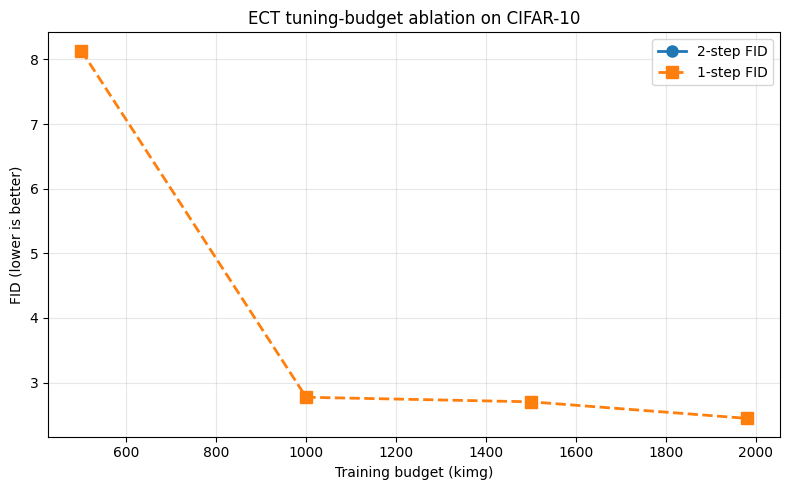

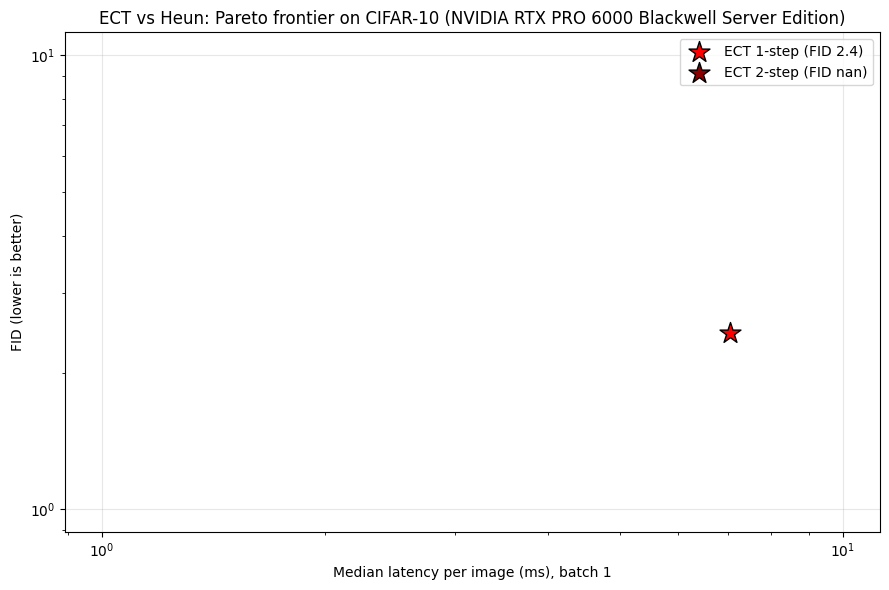


✓ All results under /content/COMP447/project/results
Files: ['.gitkeep', 'ablation_curve.png', 'ablation_fid.csv', 'heun_fid.csv', 'latency.csv', 'pareto.png']


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import json

results_dir = Path("/content/COMP447/project/results")

# Load everything that exists
ablation = pd.read_csv(results_dir / "ablation_fid.csv") if (results_dir / "ablation_fid.csv").exists() else None
heun = pd.read_csv(results_dir / "heun_fid.csv") if (results_dir / "heun_fid.csv").exists() else None
latency = pd.read_csv(results_dir / "latency.csv") if (results_dir / "latency.csv").exists() else None

print("=== Ablation data ==="); print(ablation if ablation is not None else "(missing)")
print("\n=== Heun data ==="); print(heun if heun is not None else "(missing)")
print("\n=== Latency data ==="); print(latency if latency is not None else "(missing)")

# --- Ablation curve: kimg vs FID ---
if ablation is not None and len(ablation):
    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(ablation["kimg"], ablation["fid_2step"], "o-", label="2-step FID", linewidth=2, markersize=8)
    ax.plot(ablation["kimg"], ablation["fid_1step"], "s--", label="1-step FID", linewidth=2, markersize=8)
    ax.set_xlabel("Training budget (kimg)")
    ax.set_ylabel("FID (lower is better)")
    ax.set_title("ECT tuning-budget ablation on CIFAR-10")
    ax.legend(); ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(results_dir / "ablation_curve.png", dpi=120)
    plt.show()

# --- Pareto plot: FID vs latency ---
if ablation is not None and heun is not None and latency is not None:
    best_kimg = ablation["kimg"].max()
    best_ect_1step = ablation[ablation.kimg == best_kimg]["fid_1step"].iloc[0]
    best_ect_2step = ablation[ablation.kimg == best_kimg]["fid_2step"].iloc[0]

    ect_lat_1 = latency[(latency.sampler == "ect") & (latency.steps == 1) & (latency.batch_size == 1)]
    ect_lat_2 = latency[(latency.sampler == "ect") & (latency.steps == 2) & (latency.batch_size == 1)]

    fig, ax = plt.subplots(figsize=(9, 6))
    if len(ect_lat_1):
        ax.scatter(ect_lat_1.iloc[0].median_ms, best_ect_1step, s=250, marker="*", c="red",
                   label=f"ECT 1-step (FID {best_ect_1step:.1f})", zorder=5, edgecolors="black")
    if len(ect_lat_2):
        ax.scatter(ect_lat_2.iloc[0].median_ms, best_ect_2step, s=250, marker="*", c="darkred",
                   label=f"ECT 2-step (FID {best_ect_2step:.1f})", zorder=5, edgecolors="black")

    heun_points = []
    for _, h in heun.iterrows():
        lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == 1)]
        if len(lat):
            heun_points.append((lat.iloc[0].median_ms, h.fid, h.steps))
    heun_points.sort()
    if heun_points:
        xs = [p[0] for p in heun_points]; ys = [p[1] for p in heun_points]
        ax.plot(xs, ys, "o-", c="blue", markersize=10, linewidth=2, label="Heun (varying steps)", zorder=4)
        for lat, fid, steps in heun_points:
            ax.annotate(f"{steps}", (lat, fid), textcoords="offset points", xytext=(7, 7), fontsize=10)

    ax.set_xlabel("Median latency per image (ms), batch 1")
    ax.set_ylabel("FID (lower is better)")
    gpu_label = latency.iloc[0].get("gpu", "unknown GPU") if len(latency) else ""
    ax.set_title(f"ECT vs Heun: Pareto frontier on CIFAR-10 ({gpu_label})")
    ax.legend(); ax.grid(True, alpha=0.3)
    ax.set_xscale("log"); ax.set_yscale("log")
    plt.tight_layout()
    plt.savefig(results_dir / "pareto.png", dpi=120)
    plt.show()

# --- Break-even N* ---
# NOTE: T_tune must reflect wall-clock of Cell 9 training run.
# Default: 15 min (G4). Adjust if you trained on a slower GPU.
T_TUNE_SECONDS = 15 * 60
T_TUNE_MS = T_TUNE_SECONDS * 1000

if latency is not None and heun is not None:
    rows = []
    for batch in [1, 64]:
        ect = latency[(latency.sampler == "ect") & (latency.steps == 2) & (latency.batch_size == batch)]
        if not len(ect): continue
        t_ect = ect.iloc[0].median_ms
        for _, h in heun.iterrows():
            heun_lat = latency[(latency.sampler == "heun") & (latency.steps == h.steps) & (latency.batch_size == batch)]
            if not len(heun_lat): continue
            t_heun = heun_lat.iloc[0].median_ms
            diff = t_heun - t_ect
            n_star = T_TUNE_MS / diff if diff > 0 else float("inf")
            rows.append({"batch_size": batch, "heun_steps": h.steps, "t_ect_2step_ms": t_ect,
                         "t_heun_ms": t_heun, "diff_ms": diff, "N_star": n_star})
    if rows:
        bedf = pd.DataFrame(rows)
        bedf.to_csv(results_dir / "break_even.csv", index=False)
        print("\n=== Break-even N* (ECT 2-step vs Heun N-step) ===")
        print(bedf.to_string(index=False))

print(f"\n✓ All results under {results_dir}")
print("Files:", sorted(p.name for p in results_dir.iterdir()))